# Customer Churn EDA

통신사 고객 이탈(Churn) 예측 데이터 탐색적 분석

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 스타일 설정
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")
%matplotlib inline

DATA_DIR = Path("data")
train = pd.read_csv(DATA_DIR / "train.csv")
print(f"데이터 shape: {train.shape}")
train.head()

데이터 shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


**분석**  
학습 데이터는 약 59만 4천 행, 21개 컬럼으로 구성되어 있다. `id`, 인구통계(성별·시니어·배우자·부양가족), 가입 기간(`tenure`), 서비스 옵션(전화·인터넷·부가서비스), 계약·결제·요금 정보, 그리고 타깃 `Churn`이 포함되어 있다. 상위 5행만 보면 수치형(tenure, MonthlyCharges, TotalCharges)과 범주형이 혼재해 있음을 확인할 수 있다.

## 1. 기본 정보 & 결측치

In [40]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

**분석**  
`info()`로 보면 대부분의 컬럼이 object(범주형) 또는 int64/float64이다. `TotalCharges`는 CSV에서 공백으로 들어올 수 있어 object로 읽혔을 가능성이 있으므로, 결측·공백 처리 후 숫자로 변환이 필요하다. non-null count로 결측 여부를 확인할 수 있다.

In [41]:
# 결측치 확인 (공백 문자열 포함). id는 분석/모델링 변수에서 제외.
missing = train.drop(columns=['id'], errors='ignore').isnull().sum()
# TotalCharges: CSV에서 빈 문자열로 올 수 있음 (dtype이 object/string일 때)
if 'TotalCharges' in train.columns:
    tc = train['TotalCharges']
    if pd.api.types.is_string_dtype(tc) or tc.dtype == object:
        blank_total = (tc.astype(str).str.strip() == '').sum()
        if blank_total > 0:
            missing['TotalCharges'] = blank_total
    else:
        missing['TotalCharges'] = tc.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("결측/공백이 있는 컬럼:")
    display(missing.to_frame('count'))
else:
    print("결측치 없음.")

결측치 없음.


**분석**  
결측/공백이 있는 컬럼이 있다면 위 표에 개수가 나온다. Churn 데이터에서 `TotalCharges`는 신규 가입(tenure=0 또는 매우 짧을 때)에서 빈 문자열로 들어오는 경우가 많다. 결측이 많으면 삭제·대체(예: 0 또는 중앙값) 등 전략을 정해야 한다.

In [42]:
# TotalCharges: 문자열/공백이면 숫자로 변환. 결측은 0으로 (tenure=0 구간과 맞춤)
if not pd.api.types.is_numeric_dtype(train['TotalCharges']):
    train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
train['TotalCharges'] = train['TotalCharges'].fillna(0.0)
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,594194.0,NaN,NaN,NaN,297096.5,171529.177263,0.0,148548.25,297096.5,445644.75,594193.0
gender,594194,2,Female,298738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,594194.0,NaN,NaN,NaN,0.114102,0.317936,0.0,0.0,0.0,0.0,1.0
Partner,594194,2,Yes,309554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,594194,2,No,414362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,594194.0,NaN,NaN,NaN,36.577258,25.061922,1.0,12.0,35.0,62.0,72.0
PhoneService,594194,2,Yes,557893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,594194,3,No,283384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,594194,3,Fiber optic,272386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,594194,3,No,289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**분석**  
`describe()`로 수치형 변수의 개수, 평균, 표준편차, 최소·최대, 사분위수를 확인한다. `tenure`는 0~72개월, `MonthlyCharges`·`TotalCharges`는 요금 단위로 해석하면 된다. `TotalCharges`가 NaN으로 나온 행이 있다면 결측 처리 후 다시 요약 통계를 보는 것이 좋다. 수치형 분포가 치우쳐 있으면 로그 변환·구간화를 고려할 수 있다.

## 2. 타깃(Churn) 분포

In [43]:
churn_counts = train['Churn'].value_counts()
churn_pct = train['Churn'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'count': churn_counts, 'percent': churn_pct})

,count,percent
Churn,,
No,460377,77.48
Yes,133817,22.52


**분석**  
타깃(Churn)의 Yes/No 비율을 보면 **클래스 불균형** 정도를 파악할 수 있다. Yes 비율이 지나치게 작으면(예: 5% 미만) 재표본추출(SMOTE 등) 또는 가중치 부여를, 비슷하면(예: 20~40%) 그대로 모델링해도 된다. ROC AUC 평가이므로 확률 예측이 중요하다.

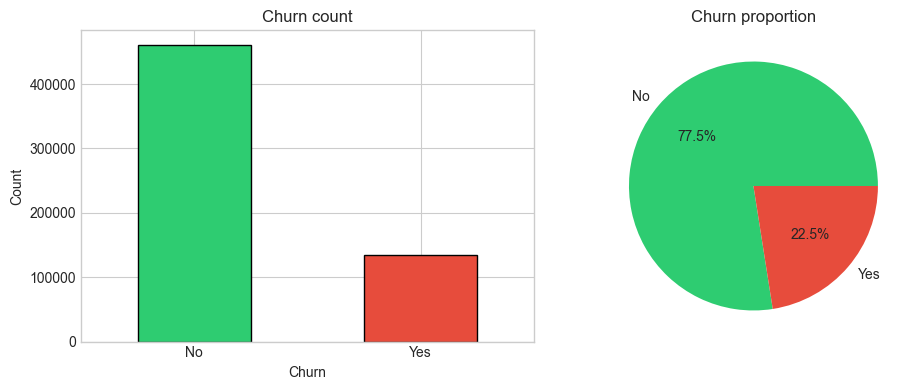

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax[0].set_title('Churn count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].set_ylabel('Count')
churn_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', labels=['No', 'Yes'], colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn proportion')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**분석**  
왼쪽 막대 그래프는 Churn Yes/No의 **절대 개수**, 오른쪽 파이 차트는 **비율**을 보여 준다. 이탈(Yes) 비율이 어느 정도인지 한눈에 파악할 수 있으며, 이후 범주형 변수별 Churn 비율과 비교할 때 기준이 된다.

## 3. 수치형 변수

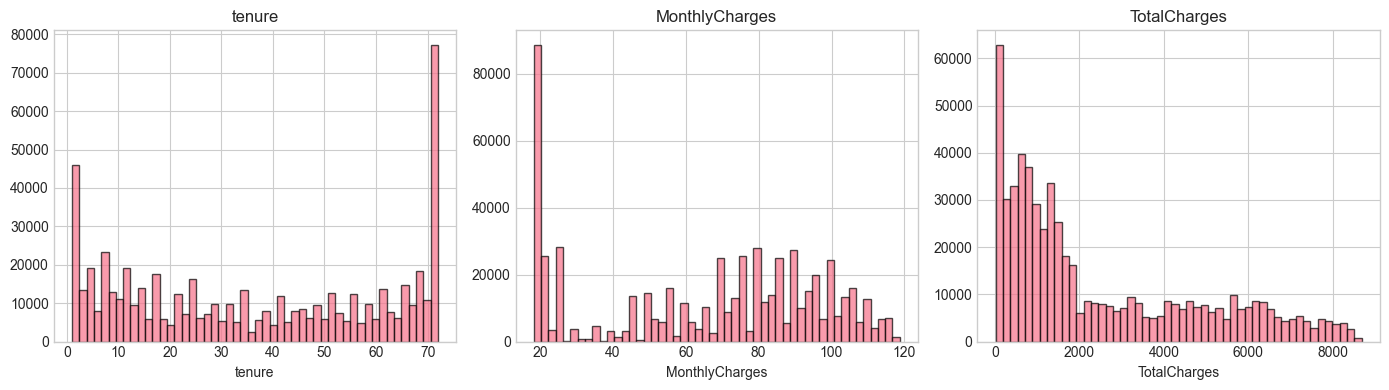

In [45]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
num_cols = [c for c in num_cols if c in train.columns]
train_num = train[num_cols].copy()
# NaN 제거 후 히스토그램
train_num_clean = train_num.dropna()
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(train_num_clean[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Dogeol\AppData\Local\Temp\ipykernel_20388\2859199260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train.drop

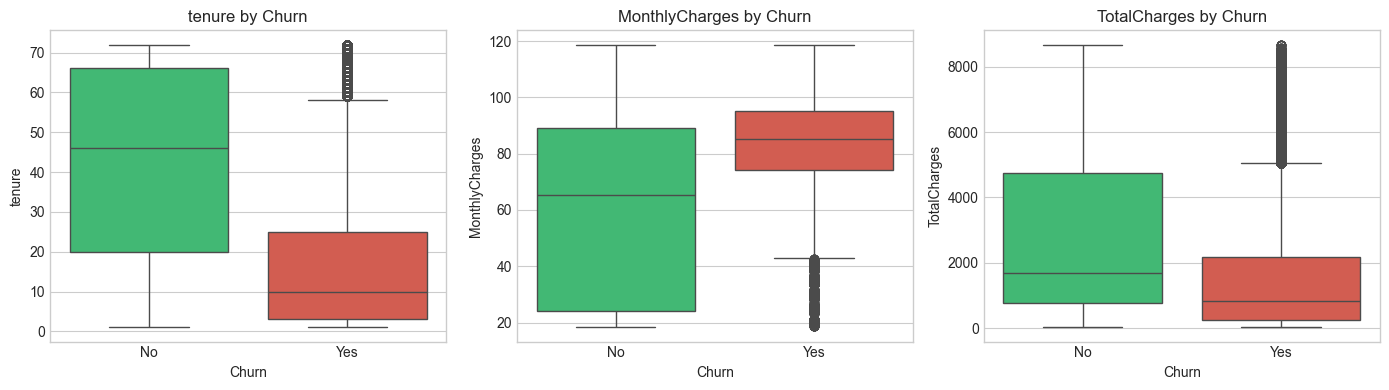

In [46]:
# 수치형 변수 vs Churn (박스플롯)
train['Churn_bin'] = (train['Churn'] == 'Yes').astype(int)
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=train.dropna(subset=[col]), x='Churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

**분석**  
`tenure`는 보통 0 근처와 중간 구간에 피크가 있을 수 있고, `MonthlyCharges`는 요금제에 따라 여러 봉우리를 보일 수 있다. `TotalCharges`는 tenure·월요금과 맞물려 오른쪽으로 꼬리가 긴 분포일 수 있다. 이상치나 0이 많으면 전처리(클리핑, 구간화 등)를 고려한다.

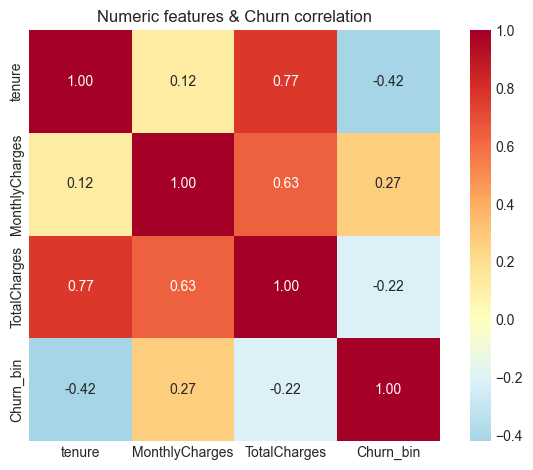

In [47]:
# 수치형 변수 간 상관관계
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']
corr_cols = [c for c in corr_cols if c in train.columns]
corr = train[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', square=True)
plt.title('Numeric features & Churn correlation')
plt.tight_layout()
plt.show()

**분석**  
Churn Yes 그룹은 **tenure가 짧고**, **TotalCharges가 낮은** 경향이 있을 수 있다(신규 가입 이탈). MonthlyCharges는 두 그룹 차이가 상대적으로 작을 수 있다. 박스플롯에서 중앙값·사분위수·이상치를 비교해 변수별로 이탈 그룹과의 차이를 해석할 수 있다.

## 4. 범주형 변수 & Churn 비율

**분석**  
`tenure`와 `TotalCharges`는 서로 강한 양의 상관이 있을 수 있다(가입 기간이 길수록 누적 요금 증가). **Churn_bin**과의 상관이 음수이면(tenure, TotalCharges) 가입 기간·누적 요금이 낮을수록 이탈 가능성이 높다는 해석이 가능하다. 다중공선성이 크면 일부 수치형만 사용하거나 정규화를 고려한다.

In [48]:
# 범주형: object/string/category 모두 포함 (pandas str dtype 환경 대응)
_exclude = {'id', 'Churn', 'Churn_bin'}
cat_candidates = train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
cat_cols = [c for c in cat_candidates if c not in _exclude and train[c].nunique() <= 20]
print("범주형 컬럼:", cat_cols)

범주형 컬럼: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


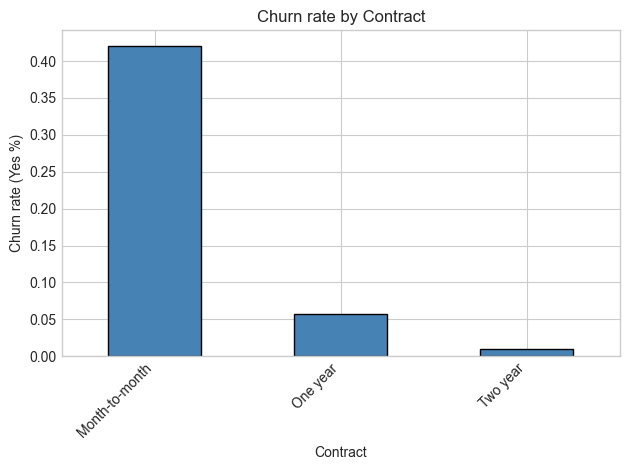

In [49]:
# 범주별 Churn 비율 (Yes 비율)
churn_rate = train.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False)
churn_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn rate by Contract')
plt.ylabel('Churn rate (Yes %)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**분석**  
범주형 변수는 인코딩(원핫, 타깃 인코딩 등)이 필요하다. 카디널리티가 너무 큰 컬럼은 제외했으므로, 위 목록을 기준으로 Churn과의 관계를 보면 모델에 넣을 feature 후보를 정하는 데 도움이 된다.

In [50]:
# 주요 범주형 변수별 Churn 비율 요약
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'Partner', 'Dependents']
key_cats = [c for c in key_cats if c in train.columns]
for col in key_cats:
    rate = train.groupby(col)['Churn_bin'].agg(['mean', 'count']).round(4)
    rate.columns = ['churn_rate', 'count']
    rate = rate.sort_values('churn_rate', ascending=False)
    print(f"\n--- {col} ---")
    display(rate)


--- Contract ---


,churn_rate,count
Contract,,
Month-to-month,0.4205,298918
One year,0.0576,108333
Two year,0.0100,186943



--- InternetService ---


,churn_rate,count
InternetService,,
Fiber optic,0.4154,272386
DSL,0.1031,181081
No,0.0143,140727



--- PaymentMethod ---


,churn_rate,count
PaymentMethod,,
Electronic check,0.4891,215372
Mailed check,0.0797,123757
Bank transfer (automatic),0.0771,121360
Credit card (automatic),0.0693,133705



--- Partner ---


,churn_rate,count
Partner,,
No,0.3246,284640
Yes,0.1338,309554



--- Dependents ---


,churn_rate,count
Dependents,,
No,0.2914,414362
Yes,0.0728,179832


**분석**  
**Contract**별로 Churn 비율이 뚜렷이 다르다. Month-to-month가 가장 높고, Two year가 가장 낮은 패턴이 typical하다. 계약 기간이 짧을수록 이탈이 많다는 해석이 가능하므로, Contract는 중요한 예측 변수로 활용하는 것이 좋다.

## 5. Tenure(가입기간) vs Churn

**분석**  
각 범주별 **churn_rate**가 높은 순으로 정렬되어 있다. InternetService에서 Fiber optic, PaymentMethod에서 Electronic check 등이 상대적으로 이탈 비율이 높을 수 있다. Partner/Dependents가 No인 경우가 Yes인 경우보다 이탈률이 높은지도 확인할 수 있다. 표에서 count가 너무 작은 범주는 노이즈일 수 있으니 주의한다.

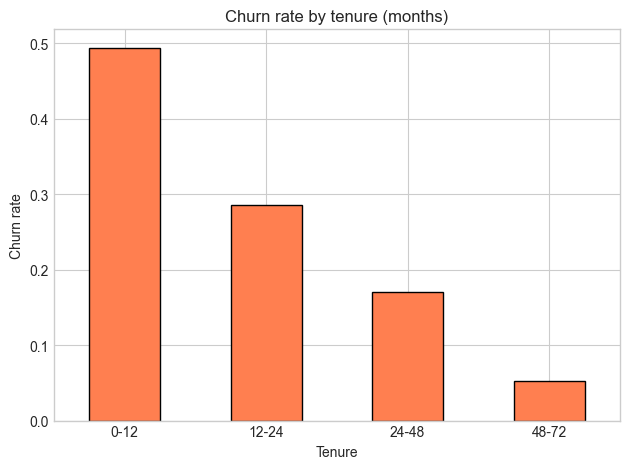

In [51]:
# 가입 기간 구간별 Churn 비율
train['tenure_bin'] = pd.cut(train['tenure'], bins=[0, 12, 24, 48, 72, 100], labels=['0-12', '12-24', '24-48', '48-72', '72+'])
rate_by_tenure = train.groupby('tenure_bin', observed=True)['Churn_bin'].mean()
rate_by_tenure.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn rate by tenure (months)')
plt.ylabel('Churn rate')
plt.xlabel('Tenure')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.5 고위험 세그먼트 및 변수 조합 분석

주요 범주형 변수 조합별 Churn 비율을 heatmap으로 보고, 상위 이탈 조합을 표로 추출해 파생변수 아이디어로 연결한다.

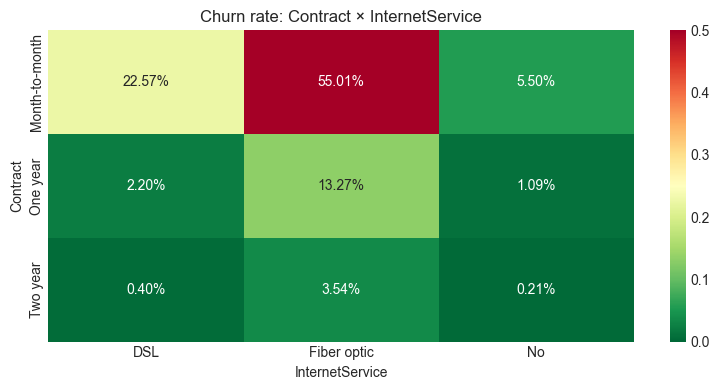

In [52]:
# 조합별 Churn 비율: Contract × InternetService
if 'Churn_bin' not in train.columns:
    train['Churn_bin'] = (train['Churn'] == 'Yes').astype(int)
rate_contract_int = train.pivot_table(values='Churn_bin', index='Contract', columns='InternetService', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(rate_contract_int, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax, vmin=0, vmax=0.5)
ax.set_title('Churn rate: Contract × InternetService')
plt.tight_layout()
plt.show()

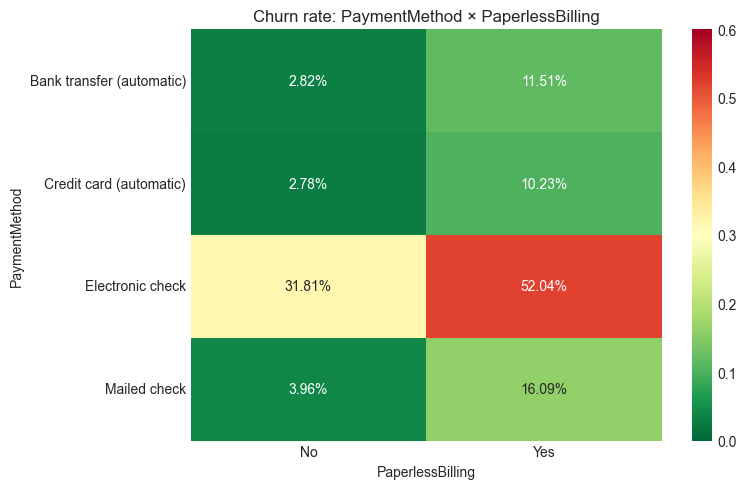

In [53]:
# 조합별 Churn 비율: PaymentMethod × PaperlessBilling
rate_pay_paper = train.pivot_table(values='Churn_bin', index='PaymentMethod', columns='PaperlessBilling', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(rate_pay_paper, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax, vmin=0, vmax=0.6)
ax.set_title('Churn rate: PaymentMethod × PaperlessBilling')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
# 상위 Churn 조합 (Contract × InternetService × PaymentMethod, 표본 1000명 이상)
combo = train.groupby(['Contract', 'InternetService', 'PaymentMethod']).agg(
    churn_rate=('Churn_bin', 'mean'), count=('Churn_bin', 'count')
).reset_index()
combo = combo[combo['count'] >= 1000].sort_values('churn_rate', ascending=False)
print('고위험 세그먼트 (상위 10개):')
display(combo.head(10))

고위험 세그먼트 (상위 10개):


,Contract,InternetService,PaymentMethod,churn_rate,count
6,Month-to-month,Fiber optic,Electronic check,0.612252,148153
7,Month-to-month,Fiber optic,Mailed check,0.429743,9515
2,Month-to-month,DSL,Electronic check,0.330947,31564
4,Month-to-month,Fiber optic,Bank transfer (automatic),0.329253,18624
5,Month-to-month,Fiber optic,Credit card (automatic),0.325684,17606
18,One year,Fiber optic,Electronic check,0.186491,16108
3,Month-to-month,DSL,Mailed check,0.176603,25345
1,Month-to-month,DSL,Credit card (automatic),0.130967,10957
0,Month-to-month,DSL,Bank transfer (automatic),0.120515,9866
10,Month-to-month,No,Electronic check,0.114053,2455


**해석**  
Month-to-month + Fiber optic, Electronic check 조합에서 Churn 비율이 특히 높다. 위 표의 고위험 세그먼트를 `high_risk_segment` 플래그 등 파생변수로 활용할 수 있다.

In [55]:
# 단변량 보강: 수치형 왜도, 구간별 Churn 비율
from scipy.stats import skew
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    s = skew(train[col].replace(0, np.nan).dropna())
    print(f'{col} 왜도: {s:.3f}')
# tenure 구간별 Churn 비율 (표본수 포함)
train['tenure_band'] = pd.cut(train['tenure'], bins=[-0.1, 6, 12, 24, 48, 100], labels=['0-6', '7-12', '13-24', '25-48', '49+'])
rate_tenure = train.groupby('tenure_band', observed=True)['Churn_bin'].agg(['mean', 'count']).round(4)
rate_tenure.columns = ['churn_rate', 'count']
print('\ntenure 구간별 Churn rate & count:')
display(rate_tenure)
train.drop(columns=['tenure_band'], inplace=True)

tenure 왜도: 0.063
MonthlyCharges 왜도: -0.289
TotalCharges 왜도: 0.909

tenure 구간별 Churn rate & count:


,churn_rate,count
tenure_band,,
0-6,0.5435,86374
7-12,0.4293,66272
13-24,0.2858,86024
25-48,0.1707,127988
49+,0.0527,227536


**변수 안정성 점검**  
id 구간별로 Churn 비율이 크게 달라지면 시간/순서 효과가 있을 수 있다. 아래에서 id 구간별 Churn 비율을 확인한다.

In [56]:
# id 구간 기반 Churn 비율 (누출/시간 효과 점검)
train['id_bin'] = pd.qcut(train['id'], q=5, labels=False, duplicates='drop')
id_churn = train.groupby('id_bin')['Churn_bin'].agg(['mean', 'count'])
id_churn.columns = ['churn_rate', 'count']
print('id 구간별 Churn rate:')
print(id_churn)
train.drop(columns=['id_bin'], inplace=True)

id 구간별 Churn rate:
        churn_rate   count
id_bin                    
0         0.237094  118839
1         0.224623  118839
2         0.223826  118838
3         0.219734  118839
4         0.220761  118839


## 5.6 합성 변수(파생변수) 설계

요금/기간, 서비스 번들, 리스크 플래그, 상호작용 변수를 정의해 train에 추가한다. 모델 학습 시 동일 규칙을 test에 적용하면 된다.

In [57]:
# 요금/기간 계열
train['avg_charge_per_month'] = train['TotalCharges'] / np.maximum(train['tenure'], 1)
train['charge_gap'] = train['TotalCharges'] - train['MonthlyCharges'] * train['tenure']
train['log_totalcharges'] = np.log1p(train['TotalCharges'])
train['monthly_charge_bin'] = pd.qcut(train['MonthlyCharges'], q=5, labels=False, duplicates='drop')
train['tenure_bin'] = pd.cut(train['tenure'], bins=[-0.1, 6, 12, 24, 48, 100], labels=[0, 1, 2, 3, 4]).astype(float)

# 서비스 번들/복잡도 (Yes 개수, No internet service 제외)
yes_cols = [c for c in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'] if c in train.columns]
train['service_count'] = train[yes_cols].apply(lambda r: (r == 'Yes').sum(), axis=1)
train['security_support_bundle'] = ((train['OnlineSecurity'] == 'Yes') & (train['TechSupport'] == 'Yes')).astype(int)
train['streaming_bundle'] = ((train['StreamingTV'] == 'Yes') & (train['StreamingMovies'] == 'Yes')).astype(int)

# 리스크 규칙형
train['is_new_customer_6'] = (train['tenure'] <= 6).astype(int)
train['is_new_customer_12'] = (train['tenure'] <= 12).astype(int)
train['is_monthly_contract'] = (train['Contract'] == 'Month-to-month').astype(int)
train['is_electronic_check'] = (train['PaymentMethod'] == 'Electronic check').astype(int)
train['is_fiber'] = (train['InternetService'] == 'Fiber optic').astype(int)
train['high_risk_segment'] = (train['is_monthly_contract'] & train['is_electronic_check'] & train['is_fiber']).astype(int)

# 상호작용
train['tenure_x_monthly'] = train['tenure'] * train['MonthlyCharges']
train['contract_x_payment'] = train['is_monthly_contract'] * train['is_electronic_check']
train['fiber_x_security_no'] = train['is_fiber'] * (train['OnlineSecurity'] != 'Yes').astype(int)

synth_cols = ['avg_charge_per_month', 'charge_gap', 'log_totalcharges', 'monthly_charge_bin', 'tenure_bin',
              'service_count', 'security_support_bundle', 'streaming_bundle', 'is_new_customer_6', 'is_new_customer_12',
              'is_monthly_contract', 'is_electronic_check', 'is_fiber', 'high_risk_segment',
              'tenure_x_monthly', 'contract_x_payment', 'fiber_x_security_no']
print('합성 변수 추가 완료. 개수:', len(synth_cols))
train[synth_cols].head(3)

합성 변수 추가 완료. 개수: 17


,avg_charge_per_month,charge_gap,log_totalcharges,monthly_charge_bin,tenure_bin,service_count,security_support_bundle,streaming_bundle,is_new_customer_6,is_new_customer_12,is_monthly_contract,is_electronic_check,is_fiber,high_risk_segment,tenure_x_monthly,contract_x_payment,fiber_x_security_no
0,57.029310,-89.05,7.411466,1,3.0,3,1,0,0,0,0,0,0,0,1742.9,0,0
1,65.141379,-252.80,8.237268,2,4.0,4,1,0,0,0,0,0,0,0,4031.0,0,0
2,100.712931,18.15,8.672888,4,4.0,3,0,1,0,0,1,1,1,1,5823.2,1,1


## 5.7 변수 효과 검증

파생변수별 단일 분리도(Mutual Information), 베이스라인 대비 CV AUC 증분, 상관/중요도로 후보를 정리한다.

In [58]:
# 파생변수별 Mutual Information (Churn과의 단변량 분리도)
from sklearn.feature_selection import mutual_info_classif
X_synth = train[synth_cols].fillna(0)
mi = mutual_info_classif(X_synth, train['Churn_bin'], random_state=42)
mi_ser = pd.Series(mi, index=synth_cols).sort_values(ascending=False)
print('Mutual Information (상위 10개):')
print(mi_ser.head(10).round(4))

Mutual Information (상위 10개):
is_monthly_contract     0.1804
avg_charge_per_month    0.1776
contract_x_payment      0.1514
tenure_x_monthly        0.1405
high_risk_segment       0.1404
log_totalcharges        0.1381
is_electronic_check     0.1376
is_fiber                0.1363
fiber_x_security_no     0.1324
tenure_bin              0.1324
dtype: float64


In [59]:
# 베이스라인 vs 파생변수 추가 시 CV AUC 비교
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

# 베이스: 원본 수치형 + 범주형(인코딩). id, Churn, Churn_bin, 합성변수 제외
base_num = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen'] if c in train.columns]
base_cat = [c for c in cat_cols if c in train.columns]
X_base = train[base_num].copy()
if base_cat:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_base[base_cat] = enc.fit_transform(train[base_cat].astype(str))
X_base = X_base.astype(float).fillna(0)

# 베이스 + 합성
X_full = X_base.join(train[synth_cols].fillna(0))

clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='auc', use_label_encoder=False)
auc_base = cross_val_score(clf, X_base, train['Churn_bin'], cv=3, scoring='roc_auc').mean()
auc_full = cross_val_score(clf, X_full, train['Churn_bin'], cv=3, scoring='roc_auc').mean()
print(f'CV-3 AUC 베이스라인: {auc_base:.4f}')
print(f'CV-3 AUC 베이스+합성: {auc_full:.4f}')
print(f'AUC delta: {auc_full - auc_base:+.4f}')

c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:54:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:55:0

CV-3 AUC 베이스라인: 0.9156
CV-3 AUC 베이스+합성: 0.9157
AUC delta: +0.0000


**AUC delta 해석**  
델타가 거의 0인 이유: (1) 베이스가 이미 Contract·InternetService·PaymentMethod 등 범주형 인코딩을 포함해 트리가 동일 정보를 분할로 학습 가능 (2) 합성변수(예: is_monthly_contract, is_fiber)가 원본 범주와 중복 (3) 트리 개수/깊이 제한으로 추가 변수 활용 여유가 작음. 아래에서 **상위 MI 합성변수만** 추가해 노이즈를 줄였을 때의 CV를 비교한다.

In [60]:
# 상위 MI 합성변수만 추가 시 CV (중복·노이즈 감소)
top_k = 8
top_synth = mi_ser.head(top_k).index.tolist()
X_top = X_base.join(train[top_synth].fillna(0))
auc_top = cross_val_score(clf, X_top, train['Churn_bin'], cv=3, scoring='roc_auc').mean()
print(f'CV-3 AUC 베이스+상위{top_k} 합성변수: {auc_top:.4f}')
print(f'베이스 대비 delta: {auc_top - auc_base:+.4f}')
print('사용한 합성변수:', top_synth)

c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:55:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:55:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:55:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CV-3 AUC 베이스+상위8 합성변수: 0.9158
베이스 대비 delta: +0.0002
사용한 합성변수: ['is_monthly_contract', 'avg_charge_per_month', 'contract_x_payment', 'tenure_x_monthly', 'high_risk_segment', 'log_totalcharges', 'is_electronic_check', 'is_fiber']


In [61]:
# 합성변수 간 상관 (중복성 점검). 상관 높은 쌍은 일부만 채택 고려
cor_synth = train[synth_cols].corr()
high_cor = [(i, j, cor_synth.loc[i, j]) for i in cor_synth.index for j in cor_synth.columns if i < j and abs(cor_synth.loc[i, j]) > 0.7]
print('상관 |r|>0.7 쌍:', high_cor[:10] if high_cor else '없음')
# 트리 1회 학습 후 합성변수 중요도
clf.fit(X_full, train['Churn_bin'])
imp = pd.Series(clf.feature_importances_, index=X_full.columns).sort_values(ascending=False)
print('\n합성변수 중 상위 중요도:', imp[imp.index.isin(synth_cols)].head(8))

상관 |r|>0.7 쌍: [('avg_charge_per_month', 'monthly_charge_bin', np.float64(0.7475284991226352)), ('log_totalcharges', 'tenure_bin', np.float64(0.8496075478557498)), ('log_totalcharges', 'tenure_x_monthly', np.float64(0.8404753071548126)), ('monthly_charge_bin', 'service_count', np.float64(0.7086999411142777)), ('tenure_bin', 'tenure_x_monthly', np.float64(0.7098714709614916)), ('service_count', 'streaming_bundle', np.float64(0.7308408423004192)), ('service_count', 'tenure_x_monthly', np.float64(0.7997919299542129)), ('is_new_customer_6', 'log_totalcharges', np.float64(-0.7218402956103509)), ('is_new_customer_6', 'tenure_bin', np.float64(-0.7331215922188411)), ('is_new_customer_12', 'log_totalcharges', np.float64(-0.7422954637536427))]


c:\Users\Dogeol\Desktop\programming\kaggle_playground\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:55:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



합성변수 중 상위 중요도: high_risk_segment       0.660448
contract_x_payment      0.127186
is_fiber                0.039906
fiber_x_security_no     0.031983
streaming_bundle        0.005284
is_electronic_check     0.003332
avg_charge_per_month    0.002668
tenure_x_monthly        0.000784
dtype: float32


## 6. 요약

**분석**  
가입 기간이 **짧을수록(0–12개월)** Churn 비율이 높고, **길어질수록(48개월 이상)** 낮아지는 경향이 typical하다. 신규 가입자 이탈이 많다는 비즈니스 해석과 맞으며, tenure(또는 tenure_bin)를 그대로 또는 구간화해 모델에 넣는 것이 유리하다.

In [62]:
print("=== EDA 요약 ===\n")
print(f"• 샘플 수: {len(train):,}, 컬럼 수: {len(train.columns)}")
print(f"• 타깃 불균형: Churn Yes {train['Churn_bin'].mean():.2%}")
print(f"• 수치형: tenure, MonthlyCharges, TotalCharges (TotalCharges 결측 확인 필요)")
print("• Churn과 상관 높을 수 있는 요인: Contract(Month-to-month), tenure 짧을수록, InternetService(Fiber), PaymentMethod 등")

=== EDA 요약 ===

• 샘플 수: 594,194, 컬럼 수: 39
• 타깃 불균형: Churn Yes 22.52%
• 수치형: tenure, MonthlyCharges, TotalCharges (TotalCharges 결측 확인 필요)
• Churn과 상관 높을 수 있는 요인: Contract(Month-to-month), tenure 짧을수록, InternetService(Fiber), PaymentMethod 등


**분석**  
EDA를 바탕으로 **모델링 시 참고할 점**을 정리하면: 
(1) 타깃 불균형에 맞는 손실 함수 또는 샘플링 
(2) TotalCharges 결측 처리 및 수치형 스케일링
(3) Contract·InternetService·PaymentMethod·tenure 등 Churn과 상관 있는 변수 적극 활용
(4) ROC AUC를 높이기 위해 확률 예측 및 칼라이브레이션 검토가 유용하다

## 7. 산출물 정리

**최종 채택 합성변수**와 **제외 이유**, **재현 가능한 생성 규칙**을 정리한다. 모델 코드(main.py) 반영 시 동일 규칙을 train/test에 적용하면 된다.

In [63]:
# 최종 채택 변수 리스트 (위 MI/CV AUC/중요도 기준으로 선별 권장)
ADOPTED_SYNTH = [
    'avg_charge_per_month', 'log_totalcharges', 'tenure_bin',
    'service_count', 'is_monthly_contract', 'is_electronic_check', 'is_fiber', 'high_risk_segment',
    'tenure_x_monthly', 'contract_x_payment', 'fiber_x_security_no'
]
# 제외 후보 (중복/저중요도로 선별 시 제거 고려)
EXCLUDED_CANDIDATES = {
    'charge_gap': 'tenure=0 구간에서 0 고정, 분산 낮음',
    'monthly_charge_bin': 'tenure_bin과 역할 중복 가능',
    'security_support_bundle': 'service_count와 상관 높을 수 있음',
    'streaming_bundle': 'MI/중요도 낮을 수 있음',
    'is_new_customer_6': 'tenure_bin으로 대체 가능',
    'is_new_customer_12': 'tenure_bin으로 대체 가능',
}

print('채택 합성변수:', ADOPTED_SYNTH)
print('\n제외 후보 및 이유:')
for v, r in EXCLUDED_CANDIDATES.items():
    print(f'  {v}: {r}')

# 재현용 생성 규칙 요약 (test 적용 시 동일 순서로 적용)
print('\n--- 재현 규칙 ---')
print('1) TotalCharges: to_numeric(..., errors="coerce"), fillna(0)')
print('2) 합성변수: 위 5.6 셀과 동일 수식 (train/test 공통)')
print('3) main.py 반영: load_data 내에서 합성변수 생성 후 feature_cols에 포함')

채택 합성변수: ['avg_charge_per_month', 'log_totalcharges', 'tenure_bin', 'service_count', 'is_monthly_contract', 'is_electronic_check', 'is_fiber', 'high_risk_segment', 'tenure_x_monthly', 'contract_x_payment', 'fiber_x_security_no']

제외 후보 및 이유:
  charge_gap: tenure=0 구간에서 0 고정, 분산 낮음
  monthly_charge_bin: tenure_bin과 역할 중복 가능
  security_support_bundle: service_count와 상관 높을 수 있음
  streaming_bundle: MI/중요도 낮을 수 있음
  is_new_customer_6: tenure_bin으로 대체 가능
  is_new_customer_12: tenure_bin으로 대체 가능

--- 재현 규칙 ---
1) TotalCharges: to_numeric(..., errors="coerce"), fillna(0)
2) 합성변수: 위 5.6 셀과 동일 수식 (train/test 공통)
3) main.py 반영: load_data 내에서 합성변수 생성 후 feature_cols에 포함
